In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/murtazaabdullah2010/fake-friends/sample_output(3).csv
/kaggle/input/datasets/murtazaabdullah2010/fake-friends/test_data(2).csv
/kaggle/input/datasets/murtazaabdullah2010/fake-friends/custom_archive.py


In [2]:
test_ds = pd.read_csv("/kaggle/input/datasets/murtazaabdullah2010/fake-friends/test_data(2).csv")
sample_sub = pd.read_csv("/kaggle/input/datasets/murtazaabdullah2010/fake-friends/sample_output(3).csv")

In [3]:
test_ds

,datapointID,text
0,0,Cleric in Najaf Refuses to Meet Iraqi Mediator...
1,1,School #39;s out to shun IE Citing security ri...
2,2,How do I begin to review a film that will soon...
3,3,ANALYSIS-Suspected Islamist killing tests Dutc...
4,4,Venezuela Boosts Taxes on Orinoco Deals &lt;p&...
...,...,...
6995,6995,35 accused of Qaeda-linked plot to bomb target...
6996,6996,Afghan President Aborts Trip After Rocket Atta...
6997,6997,European Shares at 2-Month High European share...
6998,6998,Oracle warns of exploits for latest DB flaws O...


In [4]:
from transformers import AutoModel, AutoTokenizer
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [13]:
model_n = "BAAI/bge-small-en-v1.5"

In [14]:
from sentence_transformers import SentenceTransformer

In [21]:
model = SentenceTransformer(model_n).to("cuda")

movie_concept= model.encode(["film review  movie acting actress cinema plot"])
news_concept = model.encode(["breaking news sports world politics war technology business local events terrorism"])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
tokenizer = AutoTokenizer.from_pretrained(model_n)

In [23]:
class DF(nn.Module):
    def __init__(self, df, tok):
        self.df = df
        self.texts=df["text"]
        self.tok = tok
    def __len__(self):
        return len(self.df)
    def __getitem__(self , i):
        toke= self.tok(self.texts[i], return_tensors = "pt",padding = "max_length",max_length = 256, truncation = True)
        input_ids, attn_mask = toke["input_ids"].squeeze(0), toke["attention_mask"].squeeze(0)
        return input_ids, attn_mask

test_df= DF(test_ds, tokenizer)
test_dl = DataLoader(test_df, batch_size = 4, shuffle = False , num_workers = 4, pin_memory =True)
for batch in test_dl:
    x, y= batch
    print(x.shape)
    print(y.shape)
    break

torch.Size([4, 256])
torch.Size([4, 256])


In [24]:
fake_preds = []
for idx, row  in test_ds.iterrows():
    text = row["text"]
    text = model.encode([text])
    sim_mov = model.similarity(text, movie_concept)
    sim_new = model.similarity(text, news_concept)
    if sim_mov > sim_new + 0.06:
        fake_preds.append(1)
    else:
        fake_preds.append(0)

In [25]:
class MODEL(nn.Module):
    def  __init__(self):
        super().__init__()
        self.model= AutoModel.from_pretrained("BAAI/bge-small-en-v1.5")
    def forward(self, x, x1):
        return self.model(input_ids = x, attention_mask = x1)

device = ("cuda" if torch.cuda.is_available() else "cpu")
model = MODEL().to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [26]:
embeds= []

for batch in test_dl:
    x, x1 = batch
    x, x1= x.to(device), x1.to(device)
    with torch.no_grad():
        out = model(x, x1)
    if out.pooler_output is not None:
        embeds.append(out.pooler_output)
    else:
        emebds.append(out.last_hidden_state)

In [27]:
embeds = torch.cat(embeds, dim=0)

In [28]:
len(embeds)

7000

In [29]:
embeds = embeds.cpu().numpy()

In [30]:
len(embeds)

7000

In [31]:

import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
embeds_tsne = tsne.fit_transform(embeds)



NameError: name 'plt' is not defined

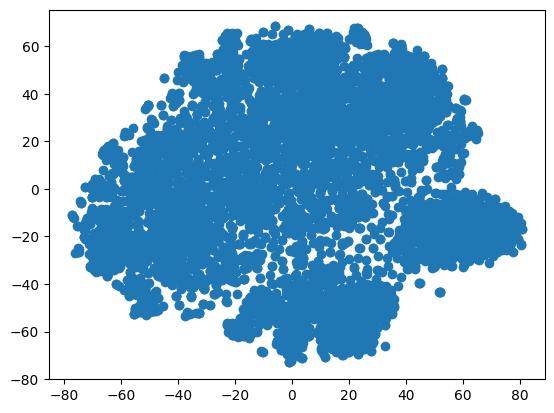

In [41]:
plt.scatter(embeds_tsne[: , 0], embeds_tsne[:, 1])

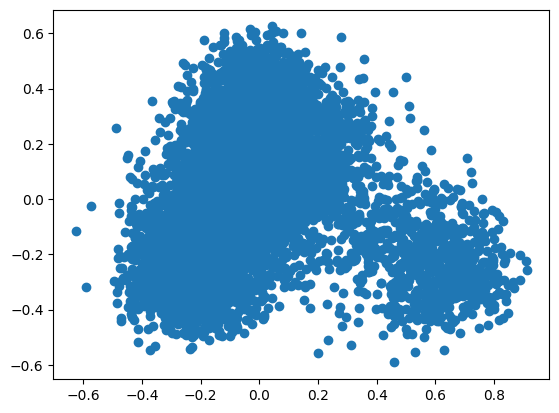

In [46]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
embeds_pca = pca.fit_transform(embeds
                              )

plt.scatter(embeds_pca[: , 0], embeds_pca[:, 1])

In [47]:
from sklearn.cluster import KMeans
scores = []

for i in range(1 ,30):
    kmeans = KMeans(n_clusters = i).fit(embeds)
    scores.append(kmeans.inertia_)

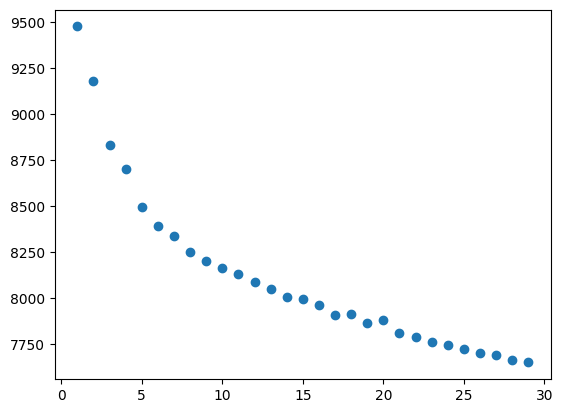

In [48]:
plt.scatter([i for i in range(1, 30)], scores)

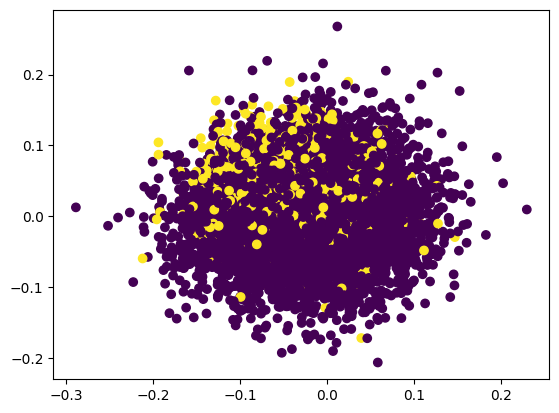

In [51]:
from sklearn.cluster import SpectralClustering

s_cluster= SpectralClustering(n_clusters = 2)
spec= s_cluster.fit_predict(embeds)

plt.scatter(embeds[:, 0] , embeds[:, 1], c = spec)

In [34]:
sub_1 = pd.DataFrame({
    "subtaskID": 1 , 
    "datapointID": test_ds["datapointID"].tolist(),
    "answer": fake_preds
    })

In [36]:
from sklearn.cluster import DBSCAN, KMeans
dbscan = DBSCAN()
kmeans_pred = KMeans(n_clusters = 7).fit_predict(embeds)


sub_2= pd.DataFrame({
    "subtaskID": 2, 
    "datapointID": test_ds["datapointID"].tolist(),
    "answer": kmeans_pred
    })

In [37]:
kmeans_pred

array([5, 3, 1, ..., 0, 3, 0], dtype=int32)

In [38]:
f_sub = pd.concat([sub_1, sub_2] , axis= 0)
f_sub

,subtaskID,datapointID,answer
0,1,0,0
1,1,1,0
2,1,2,1
3,1,3,0
4,1,4,0
...,...,...,...
6995,2,6995,6
6996,2,6996,5
6997,2,6997,0
6998,2,6998,3


In [39]:
f_sub.to_csv("suglkjfks1.csv", index = False)

In [79]:
import re
def has_spcial_char(text):
    if re.search(r'[^a-zA-Z0-9]', text):
        return "YES"
    else:
        return "NO"
test_ds["has_special_chars"]= test_ds["text"].apply(has_spcial_char)

In [80]:
def word_counts(text):
    text= list(text)
    return len(set(list(text)))

test_ds["unique_word_count"] = test_ds["text"].apply(word_counts)

def word_count(text):
    return len(list(text))

test_ds["word_count"] = test_ds["text"].apply(word_count)

def uppercase_count(text):
    t_upper = 0
    for x in list(text):
        if x.isupper():
            t_upper += 1
    return t_upper

test_ds["upper_count"] = test_ds["text"].apply(uppercase_count)

In [83]:
def sp_count(text):
    special_chars = re.findall(r"[^a-zA-Z0-9\s]", text)
    return len(special_chars)

test_ds["sp_count"]= test_ds["text"].apply(sp_count) 

In [85]:
test_ds["has_special_chars"] = test_ds["has_special_chars"].map({"YES": 1, "NO": 0})

In [86]:
test_ds

,datapointID,text,has_special_chars,unique_word_count,word_count,upper_count,sp_count
0,0,Cleric in Najaf Refuses to Meet Iraqi Mediator...,1,32,175,9,3
1,1,School #39;s out to shun IE Citing security ri...,1,35,179,9,4
2,2,How do I begin to review a film that will soon...,1,29,200,3,8
3,3,ANALYSIS-Suspected Islamist killing tests Dutc...,1,29,200,14,1
4,4,Venezuela Boosts Taxes on Orinoco Deals &lt;p&...,1,39,200,19,26
...,...,...,...,...,...,...,...
6995,6995,35 accused of Qaeda-linked plot to bomb target...,1,34,200,12,4
6996,6996,Afghan President Aborts Trip After Rocket Atta...,1,37,200,21,4
6997,6997,European Shares at 2-Month High European share...,1,29,200,8,4
6998,6998,Oracle warns of exploits for latest DB flaws O...,1,27,200,5,0


In [90]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfv = TfidfVectorizer(min_df=3,  max_features=None, 
            strip_accents='unicode', analyzer='word',token_pattern=r'\w{1,}',
            ngram_range=(1, 3), use_idf=True,smooth_idf=True,sublinear_tf=True,
            stop_words = 'english')
text= tfv.fit_transform(test_ds["text"])

In [93]:
from sklearn.decomposition import TruncatedSVD

tsvd = TruncatedSVD(n_components= 1000).fit(text)

sum(tsvd.explained_variance_ratio_)

np.float64(0.5276203152440667)

In [101]:
num_cols = [col for col in test_ds.columns if col not in ["datapointID", "text", "has_special_chars"]]
from sklearn.preprocessing import StandardScaler

scaler =StandardScaler().fit(test_ds[num_cols])
test_ds[num_cols] = scaler.transform(test_ds[num_cols])

In [106]:
from scipy.sparse import csr_matrix, hstack

In [107]:
feats = hstack([tsvd.transform(text), csr_matrix(test_ds[num_cols])])

In [109]:
kmeans = AgglomerativeClustering(n_clusters = 2).fit_predict(feats)
sub_1 = pd.DataFrame({
    "subtaskID": 1 , 
    "datapointID": test_ds["datapointID"].tolist(),
    "answer": kmeans
    })
f_sub = pd.concat([sub_1, sub_2] , axis= 0)
f_sub.to_csv("sub4.csv",index= False)